# Firefighting Device Detection with SimCLR

This notebook is self-contained for demonstration: it inspects the dataset, visualizes symbol crops, and can launch pretraining plus fine-tuning directly from notebook cells.

## Clarification about pretraining

The current project does **not** start from an externally pretrained SimCLR checkpoint.
It builds a fresh `resnet18` encoder, pretrains SimCLR on the firefighting symbol crops, and then fine-tunes a classifier on the labeled crops.

In [1]:
from pathlib import Path
import sys

def find_repo_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / 'Data').exists() and (candidate / 'firefighting_simclr').exists():
            return candidate
    raise FileNotFoundError('Could not find the repository root from the current notebook working directory.')

ROOT = find_repo_root(Path.cwd())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

ROOT

WindowsPath('C:/Users/james/Firefighting_device_detection')

In [2]:
from collections import Counter
import json
import random

import matplotlib.pyplot as plt
from PIL import Image

from firefighting_simclr.data import build_label_mapping, extract_crop, load_split_records
from firefighting_simclr.notebook_utils import load_test_metrics, make_experiment_args, clone_args
from firefighting_simclr.training import run_pretraining, run_finetuning

DATA_DIR = ROOT / 'Data'
OUTPUT_DIR = ROOT / 'outputs' / 'final_run'

print('Repo root:', ROOT)
print('Data directory exists:', DATA_DIR.exists())


Repo root: C:\Users\james\Firefighting_device_detection
Data directory exists: True


c:\Users\james\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
def show_split_summary(split: str):
    records, _ = load_split_records(DATA_DIR, split)
    raw = json.loads((DATA_DIR / split / '_annotations.coco.json').read_text(encoding='utf-8'))
    counts = Counter(record.category_name for record in records)
    return {
        'split': split,
        'images': len(raw['images']),
        'annotations': len(records),
        'unique_classes': len(counts),
        'top_5_classes': counts.most_common(5),
    }
# show the summary of each split
for split in ['train', 'valid', 'test']:
    print(show_split_summary(split))

{'split': 'train', 'images': 102, 'annotations': 2606, 'unique_classes': 40, 'top_5_classes': [('24V-power-cord', 940), ('fire-fan-manual-control-line', 341), ('i-o-module', 151), ('bus-isolation-module', 136), ('coded-smoke-detector', 133)]}
{'split': 'valid', 'images': 28, 'annotations': 755, 'unique_classes': 33, 'top_5_classes': [('24V-power-cord', 295), ('fire-fan-manual-control-line', 74), ('bus-isolation-module', 48), ('coded-smoke-detector', 42), ('i-o-module', 37)]}
{'split': 'test', 'images': 18, 'annotations': 424, 'unique_classes': 30, 'top_5_classes': [('24V-power-cord', 149), ('fire-fan-manual-control-line', 59), ('bus-isolation-module', 25), ('coded-smoke-detector', 25), ('i-o-module', 22)]}


In [5]:
label_mapping, class_names = build_label_mapping(DATA_DIR)
train_records, _ = load_split_records(DATA_DIR, 'train')
valid_records, _ = load_split_records(DATA_DIR, 'valid')

train_ids = {record.category_id for record in train_records}
valid_only = sorted({record.category_name for record in valid_records if record.category_id not in train_ids})

print('Train-supported classes:', len(class_names))
print('Validation classes not seen in training:', valid_only)

Train-supported classes: 40
Validation classes not seen in training: ['explosion-proof-smoke-detector']


In [6]:
train_records

[CropRecord(image_path=WindowsPath('C:/Users/james/Firefighting_device_detection/Data/train/3-2-1b_PNG.rf.097ded96057ba3ded0c92d916e13e9b3.jpg'), bbox=(371.0, 300.0, 49.0, 34.0), category_id=31, category_name='pressure-switch-flow-switch-start-pump-line', split='train', image_id=0, annotation_id=0),
 CropRecord(image_path=WindowsPath('C:/Users/james/Firefighting_device_detection/Data/train/3-2-1b_PNG.rf.097ded96057ba3ded0c92d916e13e9b3.jpg'), bbox=(64.0, 13.0, 34.0, 27.0), category_id=1, category_name='24V-power-cord', split='train', image_id=0, annotation_id=1),
 CropRecord(image_path=WindowsPath('C:/Users/james/Firefighting_device_detection/Data/train/3-2-1b_PNG.rf.097ded96057ba3ded0c92d916e13e9b3.jpg'), bbox=(186.0, 13.0, 28.0, 26.0), category_id=1, category_name='24V-power-cord', split='train', image_id=0, annotation_id=2),
 CropRecord(image_path=WindowsPath('C:/Users/james/Firefighting_device_detection/Data/train/3-2-1b_PNG.rf.097ded96057ba3ded0c92d916e13e9b3.jpg'), bbox=(303.0, 1

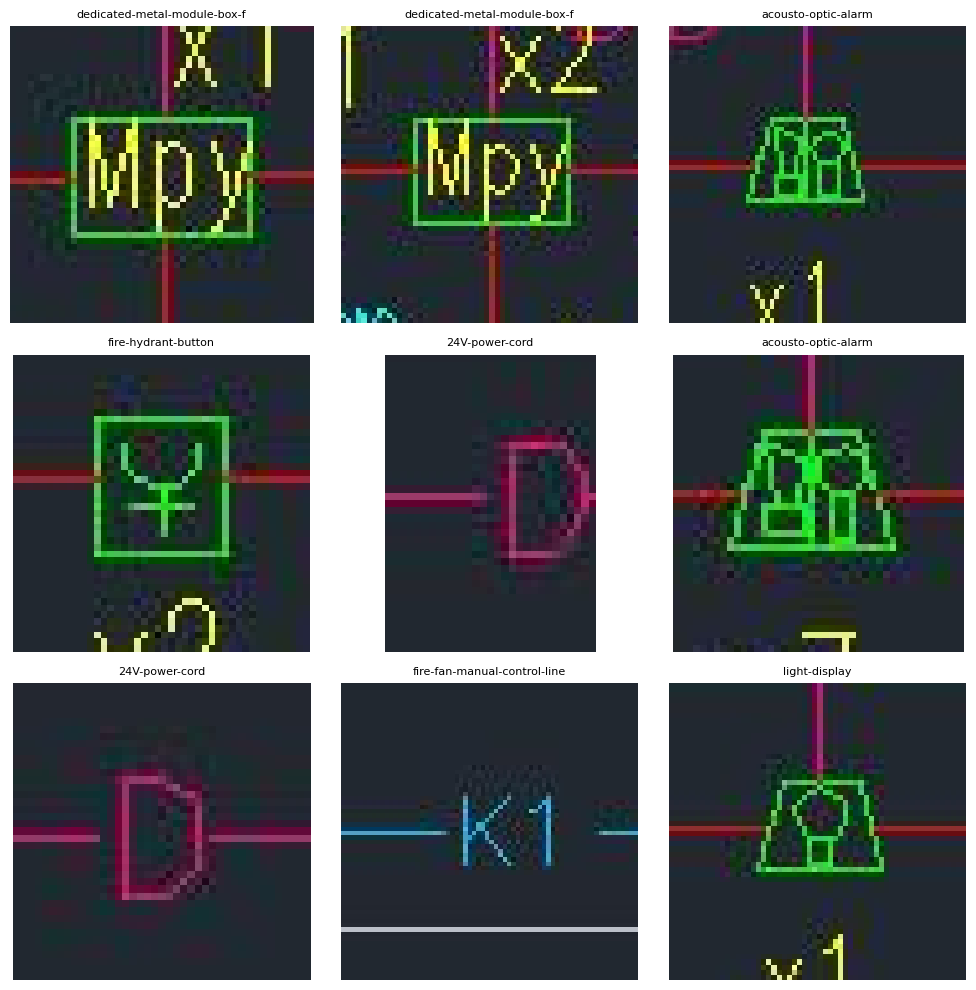

In [7]:
# Show a few random samples of the training crops and their category names
sample_records = random.sample(train_records, 9)

fig, axes = plt.subplots(3, 3, figsize=(10, 10))
for ax, record in zip(axes.flat, sample_records):
    with Image.open(record.image_path) as image:
        crop = extract_crop(image.convert('RGB'), record.bbox, padding_ratio=0.15)
    ax.imshow(crop)
    ax.set_title(record.category_name[:28], fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.show()

## Pre-Training and Finetuning

We run the pre-training and finetuning code below. 

In the pretraining phase, we optimize the resnet backbone model and the projection head in order to encode the image patches and project the encoded feature maps to vector spaces, and the vectors for patches from same image should have high cosine similarity, while patches from different images should have low cosine similarity. 

In the finetuning phase, we freeze the updates to the backbone model, and optimize a simple linear head to make predictions.

In [8]:
# The training bounding boxes has maximum of 118 pixels, after applying crop_padding=0.15, the padded crop is around 140 pixels wide
# we make image size 96 
args = make_experiment_args(
    data_dir=DATA_DIR,
    output_dir=OUTPUT_DIR,
    crop_padding=0.15, # add 15% padding to the crops, which results in around 140 pixels wide crops
    image_size=96, # resize crops to 96x96 for training
    amp=True, # automatic mixed precision
)

vars(args)


{'data_dir': WindowsPath('C:/Users/james/Firefighting_device_detection/Data'),
 'output_dir': WindowsPath('C:/Users/james/Firefighting_device_detection/outputs/final_run'),
 'backbone': 'resnet18',
 'image_size': 96,
 'batch_size': 128,
 'num_workers': 0,
 'crop_padding': 0.15,
 'seed': 42,
 'weight_decay': 0.0001,
 'amp': True,
 'simclr_epochs': 30,
 'pretrain_lr': 0.0003,
 'temperature': 0.2,
 'projection_hidden_dim': 256,
 'projection_dim': 128,
 'finetune_epochs': 25,
 'finetune_lr': 0.001,
 'dropout': 0.2,
 'label_smoothing': 0.05,
 'linear_probe_epochs': 5}

In [9]:
pretrain_args = clone_args(args, output_dir=OUTPUT_DIR / 'pretrain')
encoder_checkpoint = run_pretraining(pretrain_args)
print('Encoder checkpoint saved to:', encoder_checkpoint)


Encoder checkpoint saved to: C:\Users\james\Firefighting_device_detection\outputs\final_run\pretrain\simclr_pretrain.pt


In [10]:
finetune_args = clone_args(args, output_dir=OUTPUT_DIR / 'finetune')
classifier_checkpoint = run_finetuning(finetune_args, encoder_checkpoint=str(encoder_checkpoint))
print('Classifier checkpoint saved to:', classifier_checkpoint)


Classifier checkpoint saved to: C:\Users\james\Firefighting_device_detection\outputs\final_run\finetune\best_symbol_classifier.pt


In [11]:
metrics = load_test_metrics(OUTPUT_DIR)

print(f"Test accuracy : {metrics['accuracy']:.4f}")
print(f"Test macro F1 : {metrics['macro_f1']:.4f}")
print(f"Test loss     : {metrics['loss']:.4f}")
print(f"Samples       : {metrics['num_samples']}")
print()

print("Per-class report:")
print(f"{'Class':<52} {'Precision':>9} {'Recall':>9} {'F1':>9} {'Support':>9}")
print('-' * 92)
for class_name, scores in metrics['report'].items():
    if isinstance(scores, dict) and 'f1-score' in scores:
        print(
            f"{class_name:<52} {scores['precision']:>9.3f}"
            f" {scores['recall']:>9.3f} {scores['f1-score']:>9.3f}"
            f" {int(scores['support']):>9}"
        )


Test accuracy : 0.9929
Test macro F1 : 0.9567
Test loss     : 0.4391
Samples       : 424

Per-class report:
Class                                                Precision    Recall        F1   Support
--------------------------------------------------------------------------------------------
24V-power-cord                                           1.000     1.000     1.000       149
acousto-optic-alarm                                      1.000     1.000     1.000        17
area-display                                             1.000     1.000     1.000         3
bus-isolation-module                                     1.000     1.000     1.000        25
coded-smoke-detector                                     1.000     1.000     1.000        25
coded-temperature-detector                               1.000     1.000     1.000         4
dedicated-metal-module-box-for-fire-pump                 0.000     0.000     0.000         0
dedicated-metal-module-box-for-fire-smoke-exhaust-fan  